# Having a first look at the path data

This notebook loads the robot geometry and recorded path, visualizes the data, and compares some heading-estimation methods.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path("../data/short.json")
with DATA_PATH.open() as file:
    data = json.load(file)

robot = np.asarray(data["robot"], dtype=float)
cleaning_gadget = np.asarray(data["cleaning_gadget"], dtype=float)
path = np.asarray(data["path"], dtype=float)
path_df = pd.DataFrame(path, columns=["x", "y"])

print(f"Robot vertices: {robot.shape[0]}")
print(f"Cleaning gadget points: {cleaning_gadget.shape[0]}")
print(f"Path samples: {path.shape[0]}")
path_df.head()

Robot vertices: 4
Cleaning gadget points: 2
Path samples: 162


,x,y
0,0.001689,0.001609
1,0.001795,0.001580
2,0.006968,-0.000903
3,0.008219,0.002306
4,0.013573,-0.000665


## Robot Path

The robot path looks, as expected.
Deriving it is very noisy, as expected from measurements. This also influences the calculation of the robot heading.

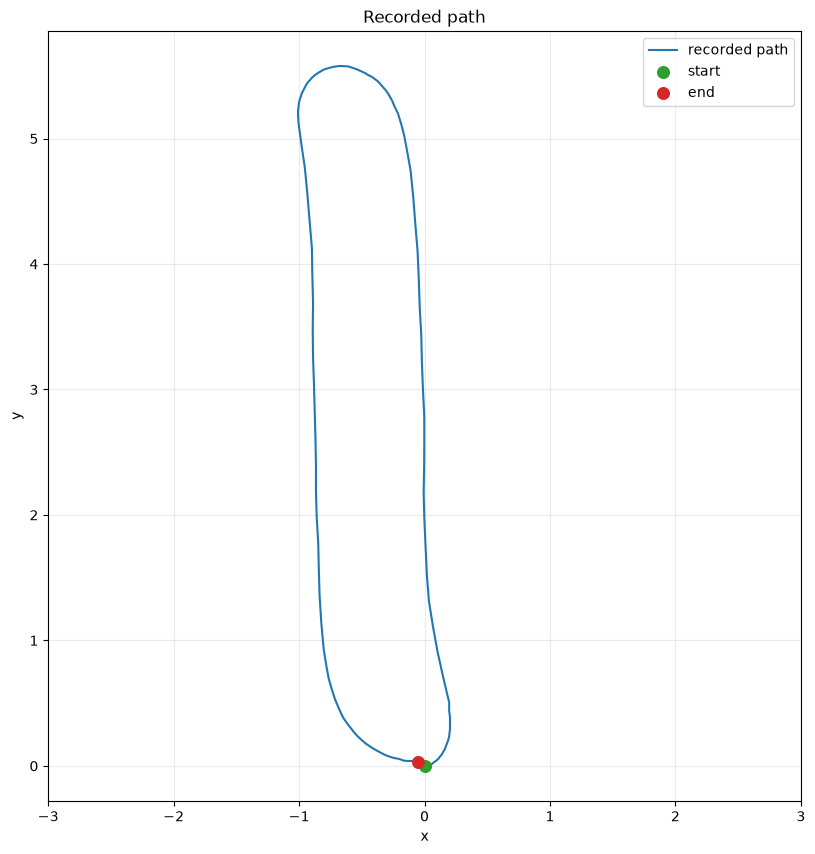

In [2]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(path[:, 0], path[:, 1], color="tab:blue", linewidth=1.5, label="recorded path")
ax.scatter(path[0, 0], path[0, 1], color="tab:green", s=70, zorder=3, label="start")
ax.scatter(path[-1, 0], path[-1, 1], color="tab:red", s=70, zorder=3, label="end")
# ax.plot(*close_polygon(robot).T, color="black", linewidth=2, label="robot")
# ax.plot(cleaning_gadget[:, 0], cleaning_gadget[:, 1], color="tab:orange", linewidth=3, label="cleaning gadget")
ax.set_title("Recorded path")
ax.set_xlabel("x")
ax.set_xlim(-3, 3)
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

In [3]:
path_df["step_length"] = np.hypot(path_df["x"].diff(), path_df["y"].diff())
path_df["incremental_heading_deg"] = np.degrees(
    np.arctan2(path_df["y"].diff(), path_df["x"].diff())
)

summary = pd.Series({
    "path_length": path_df["step_length"].sum(),
    "x_min": path_df["x"].min(),
    "x_max": path_df["x"].max(),
    "y_min": path_df["y"].min(),
    "y_max": path_df["y"].max(),
    "median_step_length": path_df["step_length"].median(),
    "max_step_length": path_df["step_length"].max(),
})
summary

path_length           12.138147
x_min                 -1.008084
x_max                  0.203465
y_min                 -0.000903
y_max                  5.578912
median_step_length     0.033303
max_step_length        0.232033
dtype: float64

   step_size_x  step_size_y  step_size
0          NaN          NaN        NaN
1     0.000106    -0.000029   0.000110
2     0.005173    -0.002483   0.005738
3     0.001251     0.003208   0.003444
4     0.005354    -0.002971   0.006123
0          NaN
1   -15.206067
2   -25.638977
3    68.698604
4   -29.023459
Name: heading_deg, dtype: float64
[        nan         nan -0.18208863  1.64650139 -1.70557176]


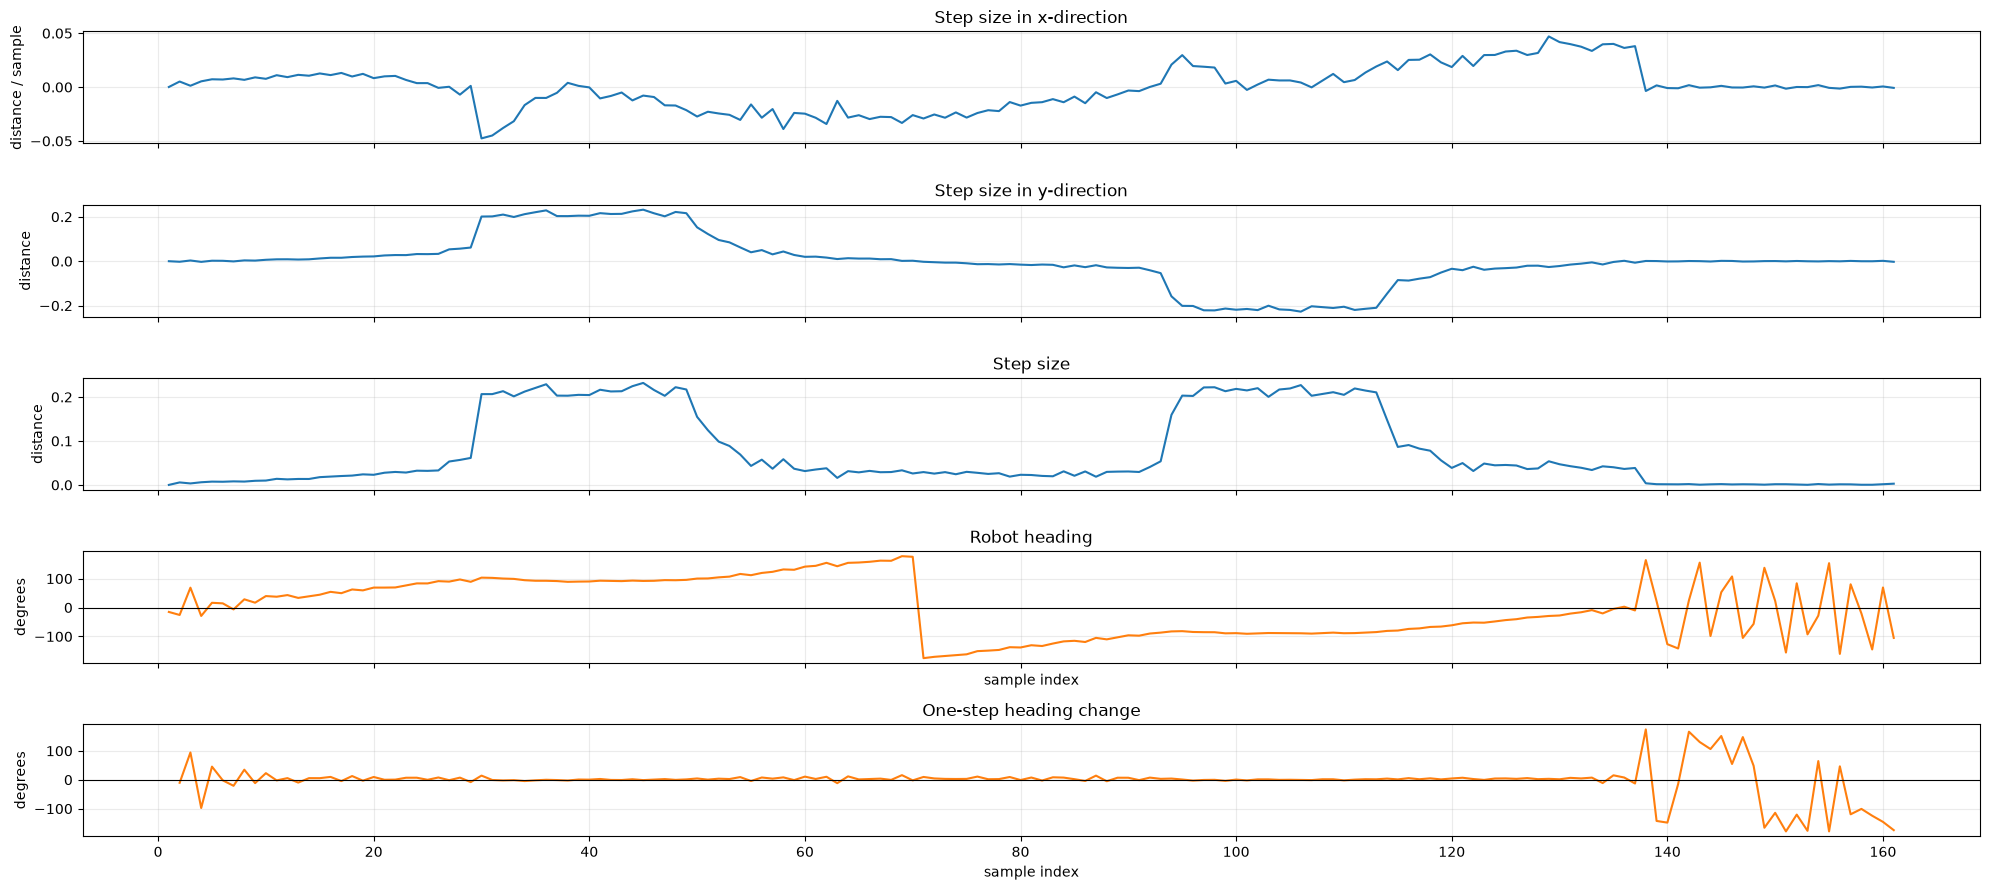

,step_size,one_step_heading_change_deg
count,161.000000,160.000000
mean,0.075392,-2.810653
std,0.082639,53.358451
min,0.000110,-178.622410
25%,0.018702,-1.654148
50%,0.033303,1.753519
75%,0.154891,6.993569
max,0.232033,174.094740


In [4]:
path_df["step_size_x"] = path_df["x"].diff()
path_df["step_size_y"] = path_df["y"].diff()
path_df["step_size"] = np.hypot(path_df["step_size_x"], path_df["step_size_y"])

print(path_df[["step_size_x", "step_size_y", "step_size"]].head())

path_df["heading_rad"] = np.arctan2(path_df["y"].diff(), path_df["x"].diff())
path_df["heading_deg"] = np.degrees(path_df["heading_rad"])
print(path_df["heading_deg"].head())
heading_change = np.arctan2(
    np.sin(np.diff(path_df["heading_rad"], prepend=np.nan)),
    np.cos(np.diff(path_df["heading_rad"], prepend=np.nan)),
)
print(heading_change[:5])
path_df["one_step_heading_change_deg"] = np.degrees(heading_change)

fig, axes = plt.subplots(5, 1, figsize=(20, 9), sharex=True)

axes[0].plot(path_df.index, path_df["step_size_x"], color="tab:blue")
axes[0].set_title("Step size in x-direction")
axes[0].set_ylabel("distance / sample")
axes[0].grid(alpha=0.25)

axes[1].plot(path_df.index, path_df["step_size_y"], color="tab:blue")
axes[1].set_title("Step size in y-direction")
axes[1].set_ylabel("distance")
axes[1].grid(alpha=0.25)

axes[2].plot(path_df.index, path_df["step_size"], color="tab:blue")
axes[2].set_title("Step size")
axes[2].set_ylabel("distance")
axes[2].grid(alpha=0.25)

axes[3].plot(path_df.index, path_df["heading_deg"], color="tab:orange")
axes[3].axhline(0, color="black", linewidth=0.8)
axes[3].set_title("Robot heading")
axes[3].set_xlabel("sample index")
axes[3].set_ylabel("degrees")
axes[3].grid(alpha=0.25)

axes[4].plot(path_df.index, path_df["one_step_heading_change_deg"], color="tab:orange")
axes[4].axhline(0, color="black", linewidth=0.8)
axes[4].set_title("One-step heading change")
axes[4].set_xlabel("sample index")
axes[4].set_ylabel("degrees")
axes[4].grid(alpha=0.25)

plt.tight_layout()
plt.show()

path_df[["step_size", "one_step_heading_change_deg"]].describe()

## Robot Geometry

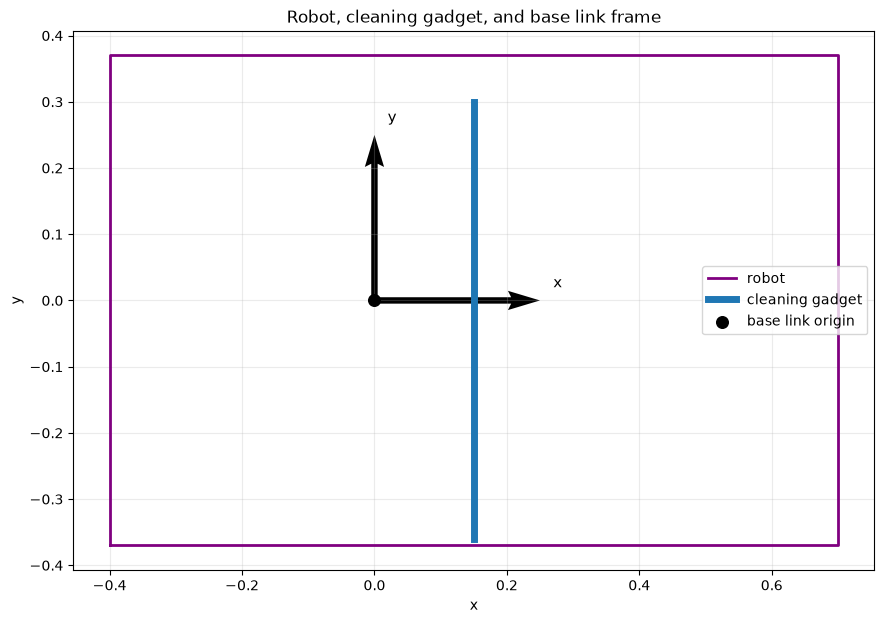

In [5]:
def close_polygon(points):
    return np.vstack([points, points[0]])

fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(*close_polygon(robot).T, color="purple", linewidth=2, label="robot")
ax.plot(cleaning_gadget[:, 0], cleaning_gadget[:, 1], color="tab:blue", linewidth=5, label="cleaning gadget")

base_link = np.array([0.0, 0.0])
ax.scatter(*base_link, color="black", s=70, zorder=4, label="base link origin")
ax.quiver(*base_link, 0.25, 0, color="black", angles="xy", scale_units="xy", scale=1, width=0.008)
ax.quiver(*base_link, 0, 0.25, color="black", angles="xy", scale_units="xy", scale=1, width=0.008)
ax.text(0.27, 0.02, "x", color="black", fontsize=11)
ax.text(0.02, 0.27, "y", color="black", fontsize=11)

ax.set_title("Robot, cleaning gadget, and base link frame")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## Preprocessing and distance-based heading

Keep the first point, then keep a new point only once it is at least **1 cm**
from the last retained point. This removes stationary jitter (especially at the
end), while allowing small movements to accumulate. The retained point represents
the cluster; we do not force the final noisy sample back into the path.

On the filtered path, expand the heading window equally before and after each
point until the endpoints are at least **0.2 m apart**. At the beginning/end,
continue expanding on the available side. Distance means the straight-line
baseline between endpoints, not accumulated path length. Heading points from
the earlier endpoint to the later one.

Both thresholds below are adjustable. If 0.2 m is unavailable, use the longest
nonzero baseline encountered. If no direction exists (a single point or a
perfectly symmetric reversal), leave the heading as `NaN`.


In [33]:
MIN_MOVEMENT = 0.01  # metres
HEADING_DISTANCE = 0.09  # metres


def remove_stationary_points(points, min_movement=MIN_MOVEMENT):
    if not np.isfinite(min_movement) or min_movement <= 0:
        raise ValueError("min_movement must be finite and positive")
    kept = []
    for i, point in enumerate(points):
        if not kept or np.linalg.norm(point - points[kept[-1]]) >= min_movement:
            kept.append(i)
    indices = np.asarray(kept, dtype=int)
    return points[indices].copy(), indices


def distance_headings(points, min_distance=HEADING_DISTANCE):
    if not np.isfinite(min_distance) or min_distance <= 0:
        raise ValueError("min_distance must be finite and positive")
    headings = np.full(len(points), np.nan)
    windows = np.zeros((len(points), 2), dtype=int)
    baselines = np.zeros(len(points))
    for i in range(len(points)):
        left = right = i
        windows[i] = [i, i]
        while left > 0 or right < len(points) - 1:
            left = max(0, left - 1)
            right = min(len(points) - 1, right + 1)
            delta = points[right] - points[left]
            baseline = np.linalg.norm(delta)
            if baseline > baselines[i]:
                headings[i] = np.arctan2(delta[1], delta[0])
                windows[i] = [left, right]
                baselines[i] = baseline
            if baseline >= min_distance:
                break
    return headings, windows, baselines


filtered_path, retained_indices = remove_stationary_points(path, MIN_MOVEMENT)
headings, heading_windows, heading_baselines = distance_headings(filtered_path, HEADING_DISTANCE)
processed_df = pd.DataFrame(filtered_path, columns=["x", "y"])
processed_df["raw_index"] = retained_indices
processed_df["heading_rad"] = headings
processed_df["heading_deg"] = np.degrees(headings)
processed_df["window_start"] = heading_windows[:, 0]
processed_df["window_end"] = heading_windows[:, 1]
processed_df["heading_baseline_m"] = heading_baselines
print(f"Retained {len(filtered_path)} of {len(path)} points")
print(f"Last retained raw index: {retained_indices[-1]}")
processed_df.tail(10)


Retained 132 of 162 points
Last retained raw index: 137


,x,y,raw_index,heading_rad,heading_deg,window_start,window_end,heading_baseline_m
122,-0.404866,0.135433,128,-0.531654,-30.461527,121,123,0.091360
123,-0.357830,0.109225,129,-0.494999,-28.361336,122,124,0.100928
124,-0.316052,0.087489,130,-0.419472,-24.033964,122,126,0.181985
125,-0.276167,0.072274,131,-0.334925,-19.189768,123,127,0.161733
126,-0.238658,0.061315,132,-0.297042,-17.019261,124,128,0.157598
127,-0.205084,0.056064,133,-0.223715,-12.817900,125,129,0.154770
128,-0.165356,0.041361,134,-0.142968,-8.191472,126,130,0.151307
129,-0.125254,0.037937,135,-0.148158,-8.488827,127,131,0.155895
130,-0.088895,0.039756,136,-0.072475,-4.152503,128,131,0.114761
131,-0.050896,0.033051,137,-0.072475,-4.152503,128,131,0.114761


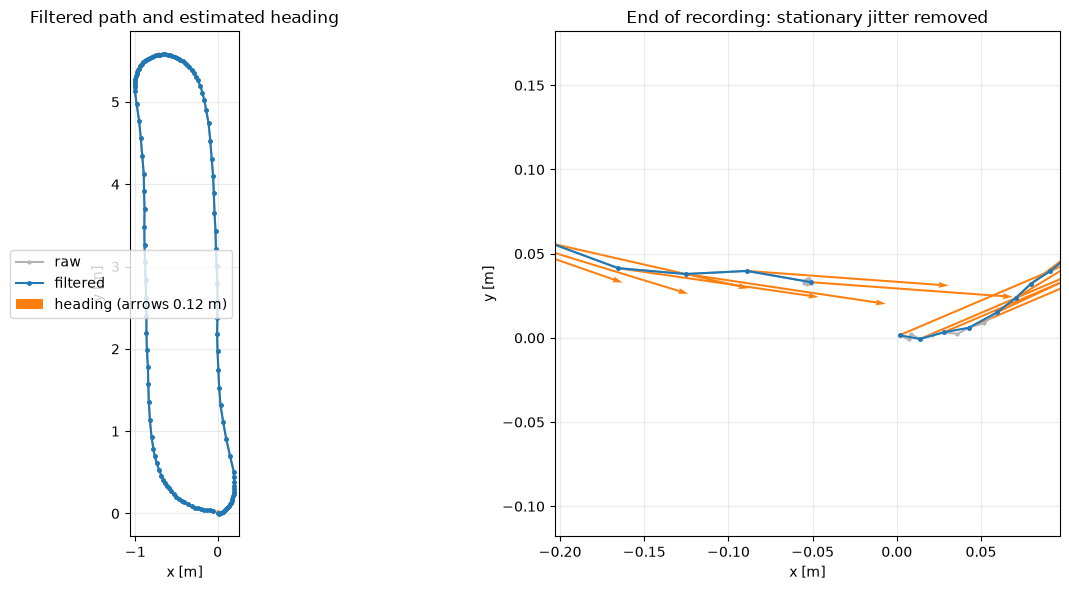

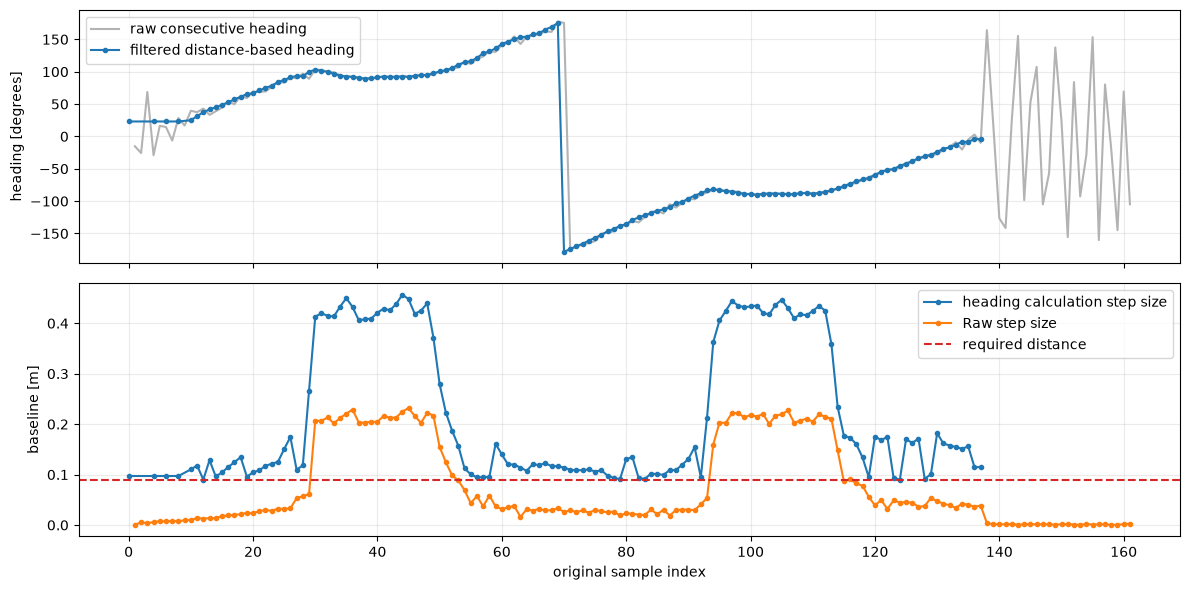

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax in axes:
    ax.plot(*path.T, ".-", color="0.7", markersize=4, label="raw")
    ax.plot(*filtered_path.T, ".-", color="tab:blue", markersize=5, label="filtered")
    ax.quiver(filtered_path[:, 0], filtered_path[:, 1],
              0.12 * np.cos(headings), 0.12 * np.sin(headings),
              angles="xy", scale_units="xy", scale=1, color="tab:orange",
              width=0.004, label="heading (arrows 0.12 m)")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.grid(alpha=0.25)
axes[0].set_title("Filtered path and estimated heading")
axes[0].legend()
axes[1].set_title("End of recording: stationary jitter removed")
axes[1].set_xlim(path[-1, 0] - 0.15, path[-1, 0] + 0.15)
axes[1].set_ylim(path[-1, 1] - 0.15, path[-1, 1] + 0.15)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(path_df.index, path_df["heading_deg"], color="0.7", label="raw consecutive heading")
axes[0].plot(retained_indices, np.degrees(headings), ".-", label="filtered distance-based heading")
axes[0].set_ylabel("heading [degrees]")
axes[0].legend()
axes[1].plot(retained_indices, heading_baselines, ".-", label="heading calculation step size")
axes[1].plot(path_df.index, path_df["step_size"], ".-", label="Raw step size")
axes[1].axhline(HEADING_DISTANCE, color="tab:red", linestyle="--", label="required distance")
axes[1].set_ylabel("baseline [m]")
axes[1].set_xlabel("original sample index")
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [35]:
TEST_MIN_MOVEMENT = 0.01  # metres
TEST_HEADING_DISTANCE = 0.2  # metres

# Small sanity checks independent of the recording.
stationary, _ = remove_stationary_points(np.array([[0., 0.], [0.001, 0.], [0., 0.002]]), min_movement=TEST_MIN_MOVEMENT)
assert len(stationary) == 1
assert np.isnan(distance_headings(stationary, min_distance=TEST_HEADING_DISTANCE)[0][0])
slow, indices = remove_stationary_points(np.array([[0., 0.], [0.004, 0.], [0.008, 0.], [0.012, 0.]]), min_movement=TEST_MIN_MOVEMENT)
assert indices.tolist() == [0, 3]  # Small steps accumulate.
curve = np.array([[-0.15, 0.], [-0.04, 0.], [0., 0.], [0.04, 0.04], [0.15, 0.2]])
angles, windows, baselines = distance_headings(curve, min_distance=TEST_HEADING_DISTANCE)
assert windows[2].tolist() == [0, 4]  # Equal counts on both sides.
assert windows[0].tolist() == [0, 4]  # Forward-only at the start.
assert windows[-1].tolist() == [2, 4]  # Backward-only at the end.
assert np.isclose(angles[2], np.arctan2(0.2, 0.3))
assert np.all(baselines >= TEST_HEADING_DISTANCE)
short = np.array([[0., 0.], [0., 0.05]])
assert np.allclose(distance_headings(short, min_distance=TEST_HEADING_DISTANCE)[0], np.pi / 2)
assert len(remove_stationary_points(np.empty((0, 2)), min_movement=TEST_MIN_MOVEMENT)[0]) == 0
assert np.all(np.linalg.norm(np.diff(filtered_path, axis=0), axis=1) >= TEST_MIN_MOVEMENT)
print("Preprocessing checks passed")


Preprocessing checks passed
